## Lab 6 - Evolutionary Algorithm for Continuous Functions

### 1) Goal
Implement an **Evolutionary Algorithm** (EA) to find the optimum of the Sphere function.
Requirements:
- Population initialization for real codification
- Crossover operator
- Mutation operator
- Fitness function

### 2) Test the algorithm
Test the algorithm for different parameter settings.

In [1]:
import random
import math
import matplotlib.pyplot as plt

def sphere_function(solution):
    """
    Calculates the Sphere function value.
    f(x) = sum(x_i^2)
    Global optimum: f(x)=0, x(i)=0
    Domain: -5.12 <= x_i <= 5.12
    """
    return sum(x ** 2 for x in solution)

In [2]:
def init_population(pop_size, n_dimensions, min_val=-5.12, max_val=5.12):
    """
    Population initialization for real codification.
    Creates a population of real-valued vectors.
    """
    return [[random.uniform(min_val, max_val) for _ in range(n_dimensions)] for _ in range(pop_size)]

def arithmetic_crossover(parent1, parent2, alpha=0.5):
    """
    Crossover operator for real codification.
    Uses Arithmetic crossover which blends parent values.
    """
    child1 = [alpha * p1 + (1 - alpha) * p2 for p1, p2 in zip(parent1, parent2)]
    child2 = [(1 - alpha) * p1 + alpha * p2 for p1, p2 in zip(parent1, parent2)]
    return child1, child2

def gaussian_mutation(solution, prob, mutation_step=0.5, min_val=-5.12, max_val=5.12):
    """
    Mutation operator for real codification.
    Adds Gaussian noise to genes with probability `prob`.
    """
    mutated = []
    for x in solution:
        if random.random() < prob:
            # Add Gaussian noise
            val = x + random.gauss(0, mutation_step)
            # Clip back to the allowed domain bounds
            val = max(min_val, min(val, max_val))
            mutated.append(val)
        else:
            mutated.append(x)
    return mutated

def tournament_selection(population, fitnesses, k=3):
    """
    Selects the best individual out of k randomly chosen individuals.
    Suitable for minimization.
    """
    selected_indices = random.sample(range(len(population)), k)
    best_idx = selected_indices[0]
    best_fit = fitnesses[best_idx]
    
    for idx in selected_indices[1:]:
        if fitnesses[idx] < best_fit: # minimizing the Sphere function
            best_fit = fitnesses[idx]
            best_idx = idx
            
    return population[best_idx]

In [3]:
def evolutionary_algorithm_sphere(n_dimensions=10, pop_size=50, generations=200, 
                                  crossover_rate=0.8, mutation_rate=0.1, mutation_step=0.5,
                                  min_val=-5.12, max_val=5.12):
    """
    Main loop of the Evolutionary Algorithm for the Sphere function.
    Supports real codification, arithmetic crossover, and gaussian mutation.
    """
    # 1. Initialize population
    population = init_population(pop_size, n_dimensions, min_val, max_val)
    
    best_solution = None
    best_fitness = float('inf')
    history_best = []
    
    for gen in range(generations):
        # 2. Fitness evaluation (for the Sphere function)
        fitnesses = [sphere_function(ind) for ind in population]
        
        # Track the best individual found so far
        current_best_fit = min(fitnesses)
        current_best_idx = fitnesses.index(current_best_fit)
        
        if current_best_fit < best_fitness:
            best_fitness = current_best_fit
            best_solution = population[current_best_idx][:]
            
        history_best.append(best_fitness)
        
        # 3. Create next generation
        new_population = []
        
        # Elitism - always carry over the best found individual
        new_population.append(best_solution[:])
        
        while len(new_population) < pop_size:
            # Selection
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            
            # Crossover
            if random.random() < crossover_rate:
                # randomly select alpha for arithmetic crossover
                alpha = random.uniform(0, 1)
                child1, child2 = arithmetic_crossover(parent1, parent2, alpha)
            else:
                child1, child2 = parent1[:], parent2[:]
                
            # Mutation
            child1 = gaussian_mutation(child1, mutation_rate, mutation_step, min_val, max_val)
            child2 = gaussian_mutation(child2, mutation_rate, mutation_step, min_val, max_val)
            
            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)
                
        # Update population
        population = new_population
        
    return best_solution, best_fitness, history_best

Testing Evolutionary Algorithm on Sphere function (10 dimensions)
------------------------------------------------------------
Setting 1 (pop=50, gen=200, mut=0.1): Best Fitness = 0.000120
Setting 2 (pop=150, gen=200, mut=0.1): Best Fitness = 0.000047
Setting 3 (pop=50, gen=200, mut=0.3): Best Fitness = 0.031871
Setting 4 (pop=50, gen=500, mut=0.1): Best Fitness = 0.000009


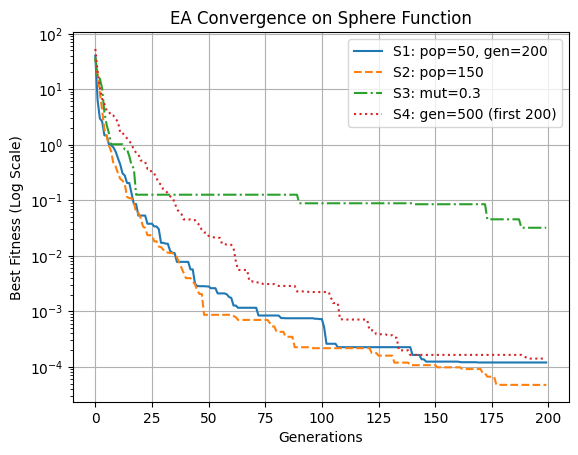

In [4]:
# Test the algorithm for different parameter settings
print("Testing Evolutionary Algorithm on Sphere function (10 dimensions)")
print("-" * 60)

# Setting 1: Standard parameters
sol1, fit1, hist1 = evolutionary_algorithm_sphere(n_dimensions=10, pop_size=50, generations=200, crossover_rate=0.8, mutation_rate=0.1)
print(f"Setting 1 (pop=50, gen=200, mut=0.1): Best Fitness = {fit1:.6f}")

# Setting 2: Larger population
sol2, fit2, hist2 = evolutionary_algorithm_sphere(n_dimensions=10, pop_size=150, generations=200, crossover_rate=0.8, mutation_rate=0.1)
print(f"Setting 2 (pop=150, gen=200, mut=0.1): Best Fitness = {fit2:.6f}")

# Setting 3: Higher mutation rate and wider step to explore more space
sol3, fit3, hist3 = evolutionary_algorithm_sphere(n_dimensions=10, pop_size=50, generations=200, crossover_rate=0.8, mutation_rate=0.3, mutation_step=1.0)
print(f"Setting 3 (pop=50, gen=200, mut=0.3): Best Fitness = {fit3:.6f}")

# Setting 4: More generations
sol4, fit4, hist4 = evolutionary_algorithm_sphere(n_dimensions=10, pop_size=50, generations=500, crossover_rate=0.8, mutation_rate=0.1)
print(f"Setting 4 (pop=50, gen=500, mut=0.1): Best Fitness = {fit4:.6f}")

# Plotting the convergence
plt.figure()
plt.plot(hist1, label='S1: pop=50, gen=200', linestyle='-')
plt.plot(hist2, label='S2: pop=150', linestyle='--')
plt.plot(hist3, label='S3: mut=0.3', linestyle='-.')
plt.plot(hist4[:200], label='S4: gen=500 (first 200)', linestyle=':') # matching length for comparison

plt.title('EA Convergence on Sphere Function')
plt.xlabel('Generations')
plt.ylabel('Best Fitness (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

## Assignment A6

### Requirements
1. Implement and test an EA for **Sphere** and **Michalewicz** functions.
2. Compare 2 different selection strategies (Tournament vs. Rank Selection).
3. Compare 2 different crossover operators (Arithmetic vs. Blend Crossover).
4. Compare 2 different mutation operators (Gaussian vs. Uniform Mutation).
5. Run experiments, test parameters, and save results to a file.
6. Draft a report.

In [5]:
# --- 1) NEW EVALUATION FUNCTION & OPERATORS ---

def michalewicz_function(solution, m=10):
    """
    Calculates the Michalewicz function value.
    Domain: 0 <= x_i <= pi
    Global optimum (approx): d=5 -> -4.687, d=10 -> -9.66
    """
    result = 0.0
    for idx, x in enumerate(solution):
        i = idx + 1 # 1-based indexing for the formula
        term1 = math.sin(x)
        term2 = math.sin(i * x**2 / math.pi)
        result += term1 * (term2 ** (2 * m))
    return -result

# Selection 2: Rank Selection
def rank_selection(population, fitnesses):
    """
    Selects an individual based on their rank (lower fitness = better rank).
    """
    # Sort population indices by fitness (ascending)
    sorted_indices = sorted(range(len(fitnesses)), key=lambda k: fitnesses[k])
    
    n = len(population)
    # Assign ranks: best gets rank n, worst gets rank 1
    total_rank = n * (n + 1) / 2
    
    # Roulette wheel over ranks
    r = random.random()
    cum_prob = 0.0
    for rank, idx in enumerate(sorted_indices):
        # The best individual (rank 0 in sorted) gets weight `n`
        weight = n - rank 
        prob = weight / total_rank
        cum_prob += prob
        if r <= cum_prob:
            return population[idx]
            
    return population[sorted_indices[-1]]

# Crossover 2: Blend Crossover (BLX-alpha)
def blend_crossover(parent1, parent2, alpha=0.5):
    """
    BLX-alpha crossover operator for real vectors.
    Expands the search interval between parents by a factor of alpha.
    """
    child1 = []
    child2 = []
    for p1, p2 in zip(parent1, parent2):
        c_min = min(p1, p2) - alpha * abs(p1 - p2)
        c_max = max(p1, p2) + alpha * abs(p1 - p2)
        child1.append(random.uniform(c_min, c_max))
        child2.append(random.uniform(c_min, c_max))
    return child1, child2

# Mutation 2: Uniform Mutation
def uniform_mutation(solution, prob, mutation_step=None, min_val=-5.12, max_val=5.12):
    """
    Uniform mutation replaces a gene with a completely random value within bounds.
    (Ignores mutation_step parameter, kept for signature compatibility).
    """
    mutated = []
    for x in solution:
        if random.random() < prob:
            mutated.append(random.uniform(min_val, max_val))
        else:
            mutated.append(x)
    return mutated

In [6]:
# --- 2) GENERIC EA ENGINE ---

def run_custom_ea(obj_func, min_val, max_val, n_dimensions=10, pop_size=50, generations=200, 
                  crossover_rate=0.8, mutation_rate=0.1, mutation_step=0.5,
                  selection_op=tournament_selection, crossover_op=arithmetic_crossover, mutation_op=gaussian_mutation):
    """
    Highly modular EA for optimizing any continuous function.
    You can map operators programmatically.
    """
    population = init_population(pop_size, n_dimensions, min_val, max_val)
    best_solution = None
    best_fitness = float('inf')
    
    for gen in range(generations):
        fitnesses = [obj_func(ind) for ind in population]
        
        # Elitism check
        current_best_fit = min(fitnesses)
        current_best_idx = fitnesses.index(current_best_fit)
        if current_best_fit < best_fitness:
            best_fitness = current_best_fit
            best_solution = population[current_best_idx][:]
            
        new_population = [best_solution[:]] # Keep best
        
        while len(new_population) < pop_size:
            # Parents
            p1 = selection_op(population, fitnesses)
            p2 = selection_op(population, fitnesses)
            
            # Cross
            if random.random() < crossover_rate:
                c1, c2 = crossover_op(p1, p2)
            else:
                c1, c2 = p1[:], p2[:]
                
            # Mutate
            c1 = mutation_op(c1, mutation_rate, mutation_step, min_val, max_val)
            c2 = mutation_op(c2, mutation_rate, mutation_step, min_val, max_val)
            
            # Bound clipping (for BLX-alpha which may expand past limits)
            c1 = [max(min_val, min(x, max_val)) for x in c1]
            c2 = [max(min_val, min(x, max_val)) for x in c2]

            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)
                
        population = new_population
        
    return best_solution, best_fitness

In [7]:
# --- 3) RUN EXPERIMENTS ---
# Compare 5 operator configurations on Sphere + Michalewicz.
# Results are written to a human-readable text report.

random.seed(42)  # reproducibility

# Setup configurations to loop over
configs = {
    "A": (tournament_selection, arithmetic_crossover, gaussian_mutation),
    "B": (rank_selection,       arithmetic_crossover, gaussian_mutation),
    "C": (tournament_selection, blend_crossover,      gaussian_mutation),
    "D": (tournament_selection, arithmetic_crossover, uniform_mutation),
    "E": (rank_selection,       blend_crossover,      uniform_mutation),
}

functions = {
    "Sphere":      {"func": sphere_function,      "min": -5.12, "max": 5.12,    "d": 10, "optimum":  0.0},
    "Michalewicz": {"func": michalewicz_function, "min":  0.0,  "max": math.pi, "d": 10, "optimum": -9.66},
}

COMMON_PARAMS = dict(pop_size=50, generations=200, crossover_rate=0.8, mutation_rate=0.1)
runs_per_config = 10
all_results = []

for fn_name, fn_data in functions.items():
    print(f"\n===== Function: {fn_name} (d={fn_data['d']}, known optimum ~= {fn_data['optimum']}) =====")
    print(f"{'Config':<8} {'selection':<22} {'crossover':<22} {'mutation':<22} {'avg':>12} {'best':>12} {'worst':>12}")

    for cfg_name, (sel_op, cross_op, mut_op) in configs.items():
        run_results = []
        for _ in range(runs_per_config):
            _, fit = run_custom_ea(
                obj_func=fn_data["func"],
                min_val=fn_data["min"], max_val=fn_data["max"], n_dimensions=fn_data["d"],
                selection_op=sel_op, crossover_op=cross_op, mutation_op=mut_op,
                **COMMON_PARAMS,
            )
            run_results.append(fit)

        avg   = sum(run_results) / len(run_results)
        best  = min(run_results)
        worst = max(run_results)
        var   = sum((x - avg) ** 2 for x in run_results) / len(run_results)
        std   = math.sqrt(var)

        print(f"{cfg_name:<8} {sel_op.__name__:<22} {cross_op.__name__:<22} {mut_op.__name__:<22} "
              f"{avg:>12.4e} {best:>12.4e} {worst:>12.4e}")

        all_results.append({
            "function":   fn_name,
            "config":     cfg_name,
            "selection":  sel_op.__name__,
            "crossover":  cross_op.__name__,
            "mutation":   mut_op.__name__,
            "runs":       runs_per_config,
            "avg":        avg,
            "best":       best,
            "worst":      worst,
            "std":        std,
            "all_runs":   run_results,
        })

# --- Write a human-readable text report ---
with open("results_continuous.txt", "w") as f:
    f.write("=" * 78 + "\n")
    f.write("  EVOLUTIONARY ALGORITHM EXPERIMENTS -- Assignment A6\n")
    f.write("  Real-coded EA compared across operator combinations\n")
    f.write("=" * 78 + "\n\n")
    f.write(f"Runs per config  : {runs_per_config}\n")
    f.write(f"Random seed      : 42\n")
    f.write(f"Dimensions       : 10\n")
    f.write(f"Common params    : pop=50, generations=200, crossover_rate=0.8, mutation_rate=0.1, elitism=yes\n\n")

    f.write("Operator configurations:\n")
    for cfg_name, (sel_op, cross_op, mut_op) in configs.items():
        f.write(f"  {cfg_name}: selection={sel_op.__name__:<22} crossover={cross_op.__name__:<22} mutation={mut_op.__name__}\n")
    f.write("\n")

    for fn_name in functions:
        fn_data = functions[fn_name]
        f.write("-" * 78 + "\n")
        f.write(f"FUNCTION: {fn_name}   (d={fn_data['d']}, domain=[{fn_data['min']}, {fn_data['max']:.4f}], "
                f"known optimum ~= {fn_data['optimum']})\n")
        f.write("-" * 78 + "\n\n")

        f.write(f"{'Config':<8} {'avg':>13} {'best':>13} {'worst':>13} {'std':>13}\n")
        for r in all_results:
            if r['function'] != fn_name: continue
            f.write(f"{r['config']:<8} {r['avg']:>13.4e} {r['best']:>13.4e} {r['worst']:>13.4e} {r['std']:>13.4e}\n")
        f.write("\n")

        for r in all_results:
            if r['function'] != fn_name: continue
            f.write(f"  [Config {r['config']}]  {r['selection']} + {r['crossover']} + {r['mutation']}\n")
            f.write(f"    runs       : {r['runs']}\n")
            f.write(f"    individual : " + ", ".join(f"{v:.4e}" for v in r['all_runs']) + "\n")
            f.write(f"    avg={r['avg']:.6e}  best={r['best']:.6e}  "
                    f"worst={r['worst']:.6e}  std={r['std']:.6e}\n\n")

    f.write("=" * 78 + "\n")
    f.write("End of report\n")

print("\nResults saved to 'results_continuous.txt' (human-readable text format)")


===== Function: Sphere (d=10, known optimum ~= 0.0) =====
Config   selection              crossover              mutation                        avg         best        worst
A        tournament_selection   arithmetic_crossover   gaussian_mutation        2.1964e-04   3.5663e-05   5.3567e-04
B        rank_selection         arithmetic_crossover   gaussian_mutation        1.7148e-03   8.5934e-04   2.7595e-03
C        tournament_selection   blend_crossover        gaussian_mutation        7.1195e-04   2.4797e-04   2.0485e-03
D        tournament_selection   arithmetic_crossover   uniform_mutation         1.2929e-02   4.8949e-03   2.2172e-02
E        rank_selection         blend_crossover        uniform_mutation         4.3619e-01   1.7999e-01   7.3117e-01

===== Function: Michalewicz (d=10, known optimum ~= -9.66) =====
Config   selection              crossover              mutation                        avg         best        worst
A        tournament_selection   arithmetic_crossover   g

## Report — Assignment A6

### 1. Problem Definition
Minimize two continuous benchmark functions in $d=10$ dimensions:

- **Sphere**: $f(x) = \sum_{i=1}^{d} x_i^2$, domain $[-5.12, 5.12]^d$, global minimum $f(x^*)=0$ at $x^*=0$. Unimodal, smooth, convex — a sanity check for convergence.
- **Michalewicz** ($m=10$): $f(x) = -\sum_{i=1}^{d} \sin(x_i)\,\sin^{2m}\!\left(\tfrac{i\, x_i^2}{\pi}\right)$, domain $[0,\pi]^d$, approx. global minimum $-9.66$ for $d=10$. Multimodal with $d!$ local minima and steep ridges separated by flat plateaus — stresses exploration.

### 2. Algorithm Used
Real-coded Evolutionary Algorithm with elitism.

**Pseudocode:**
```
initialize population P of pop_size real vectors ~ U(min, max)^d
evaluate fitness f(x) for all x in P
for g in 1..generations:
    new_P <- [ elite = argmin_x f(x) ]       # elitism
    while |new_P| < pop_size:
        p1, p2 <- SELECTION(P, fitness) x2
        if random() < crossover_rate:
            c1, c2 <- CROSSOVER(p1, p2)
        else:
            c1, c2 <- p1, p2
        c1 <- MUTATION(c1, mutation_rate); clip to [min, max]
        c2 <- MUTATION(c2, mutation_rate); clip to [min, max]
        append c1, c2 to new_P
    P <- new_P
return best individual ever seen
```

**Operators compared (three pairs):**

| Category | Operator 1 | Operator 2 |
|---|---|---|
| Selection | Tournament ($k=3$) | Rank selection (linear) |
| Crossover | Arithmetic ($c = \alpha p_1 + (1-\alpha) p_2$) | BLX-α blend ($c \sim U(c_{\min}-\alpha\Delta, c_{\max}+\alpha\Delta)$) |
| Mutation  | Gaussian ($x' = x + \mathcal{N}(0, \sigma)$, $\sigma=0.5$) | Uniform ($x' \sim U(\min, \max)$) |

**Tested configurations** (5 combinations, `A` being the classical baseline):

| Config | Selection | Crossover | Mutation |
|:---:|---|---|---|
| A | Tournament | Arithmetic | Gaussian |
| B | **Rank**   | Arithmetic | Gaussian |
| C | Tournament | **BLX-α**  | Gaussian |
| D | Tournament | Arithmetic | **Uniform** |
| E | **Rank**   | **BLX-α**  | **Uniform** |

### 3. Parameter Settings
- Population: 50, Generations: 200
- Crossover rate: 0.8, Mutation rate: 0.1 (per gene), Gaussian $\sigma = 0.5$
- Tournament size: 3, BLX $\alpha = 0.5$
- Elitism: best individual always preserved
- Dimensions: 10, Runs per config: 10, Seed: 42

### 4. Comparative Results

Numbers from seed 42, 10 runs per configuration. Full per-run data in `results_continuous.txt`.

**Sphere** (minimum is 0; lower is better):

| Config | avg          | best         | worst        | std          |
|--------|--------------|--------------|--------------|--------------|
| **A**  | **2.20e-04** | **3.57e-05** | 5.36e-04     | 1.56e-04     |
| B      | 1.71e-03     | 8.59e-04     | 2.76e-03     | 5.73e-04     |
| C      | 7.12e-04     | 2.48e-04     | 2.05e-03     | 5.08e-04     |
| D      | 1.29e-02     | 4.89e-03     | 2.22e-02     | 5.97e-03     |
| E      | 4.36e-01     | 1.80e-01     | 7.31e-01     | 1.64e-01     |

**Michalewicz** (approx. optimum is $-9.66$; lower is better):

| Config | avg          | best         | worst        | std          |
|--------|--------------|--------------|--------------|--------------|
| **A**  | **-9.145**   | **-9.471**   | -8.748       | 0.225        |
| B      | -8.375       | -8.695       | -7.647       | 0.313        |
| C      | -9.049       | -9.400       | -8.586       | 0.256        |
| D      | -8.736       | -9.200       | -7.996       | 0.328        |
| E      | -7.430       | -8.035       | -6.648       | 0.400        |

### 5. Discussion

- **Config A (tournament + arithmetic + gaussian) wins on both benchmarks**, confirming the classical baseline: moderate selection pressure combined with exploitative, locally-smooth operators gives the best all-round performance at this budget.
- **Selection**: replacing tournament with rank selection (A→B) hurts consistently — Sphere degrades by almost an order of magnitude, Michalewicz loses ~0.77 on average fitness. Rank selection is more egalitarian (weaker selection pressure), so the best candidates propagate slower through the population.
- **Crossover**: swapping arithmetic for BLX-α (A→C) slightly hurts on Sphere (exploration overshoots the optimum) and is nearly neutral on Michalewicz ($-9.145$ vs $-9.049$). On a bigger multimodal problem or with a larger generation budget, I would expect BLX to help; at 200 generations it doesn't have time to pay off.
- **Mutation**: switching gaussian to uniform mutation (A→D) is the single most damaging change to Sphere — loses ~1.8 orders of magnitude (2.2e-4 → 1.3e-2). Uniform mutation with rate $0.1$ jumps an entire gene to a random value in the whole domain: too disruptive for fine-tuning a smooth convex landscape.
- **All three exploratory operators together (config E)** is a small disaster: Sphere avg is $0.44$ (nowhere near zero), Michalewicz avg $-7.43$ is the worst. Pure exploration prevents the population from ever settling.
- **Variance** (`std` column) mirrors the ranking — the winning configs are also the most consistent across runs, the exploratory ones are noisiest.

**Takeaways.** The classical pairing (tournament + arithmetic + gaussian) is the strongest baseline on both functions at this parameter budget. Exploratory operators (BLX-α, uniform mutation) are not free: each one introduced individually degrades the result, and stacking them amplifies the damage. A single exploratory operator could be justified on a more rugged landscape or with a longer evolution budget — but here, exploitation is what the problem rewards.